In [1]:
import pandas as pd 
median_tpm_by_tissue = pd.read_csv("data/median_tpm_by_tissue.gct", sep='\t',skiprows=2, header=0)
median_tpm_by_tissue.head()



,Name,Description,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta,Artery_Coronary,Artery_Tibial,Bladder,Brain_Amygdala,...,Spleen,Stomach,Stomach_Mixed_Cell,Stomach_Mucosa,Stomach_Muscularis,Testis,Thyroid,Uterus,Vagina,Whole_Blood
0,ENSG00000290825.2,DDX11L16,0.00000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.011780,...,0.00000,0.00000,0.014928,0.012652,0.015991,0.073208,0.00000,0.00000,0.00000,0.0000
1,ENSG00000223972.6,DDX11L1,0.00000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.000000,...,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.0000
2,ENSG00000310526.1,WASH7P,2.45431,1.9053,1.75253,2.3178,2.21944,1.66539,3.14825,0.565228,...,5.04503,2.04517,1.868420,1.507490,1.909350,3.126710,4.01324,4.92657,3.85789,2.2098
3,ENSG00000243485.6,MIR1302-2HG,0.00000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.000000,...,0.00000,0.00000,0.000000,0.000000,0.000000,0.036257,0.00000,0.00000,0.00000,0.0000
4,ENSG00000237613.3,FAM138A,0.00000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.012860,...,0.00000,0.00000,0.015325,0.013091,0.018168,0.000000,0.00000,0.00000,0.00000,0.0000


In [4]:
tissue_metadata = pd.read_csv("data/sample_meta_data.txt", sep='\t', header=0, low_memory=False)

def smtsd_to_median_tissue_name(tissue_name):
    return (
        tissue_name
        .replace(' - ', '_')
        .replace(' (', '_')
        .replace(')', '')
        .replace(' ', '_')
    )

tissue_metadata = tissue_metadata.assign(
    median_tpm_tissue=tissue_metadata['SMTSD'].map(smtsd_to_median_tissue_name)
)
available_tissues = pd.Index(median_tpm_by_tissue.columns[2:])
tissue_metadata = tissue_metadata[tissue_metadata['median_tpm_tissue'].isin(available_tissues)].copy()

tissue_sample_counts = (
    tissue_metadata['median_tpm_tissue']
    .value_counts()
    .reindex(available_tissues, fill_value=0)
    .rename('sample_size')
)

tissue_sample_ids = (
    tissue_metadata.groupby('median_tpm_tissue')['SAMPID']
    .agg(list)
    .reindex(available_tissues, fill_value=[])
    .rename('sample_ids')
)

matched_tissues = pd.concat([tissue_sample_counts, tissue_sample_ids], axis=1).rename_axis('median_tpm_tissue').reset_index()
matched_tissues['low_sample_size'] = matched_tissues['sample_size'] < 100

matched_tissues.style.apply(
    lambda row: ['background-color: #ffd7d7' if row['low_sample_size'] else '' for _ in row],
    axis=1,
)
matched_tissues[matched_tissues['low_sample_size'] == True].head()

/tmp/ipykernel_1474997/3993935847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tissue_metadata = tissue_metadata.assign(


,median_tpm_tissue,sample_size,sample_ids,low_sample_size
23,Cervix_Ectocervix,43,"[GTEX-N7MT-0826-SM-EV794, GTEX-N7MT-0826-SM-GH...",True
24,Cervix_Endocervix,45,"[GTEX-N7MT-0926-SM-GLFXC, GTEX-N7MT-0926-SM-HA...",True
27,Colon_Transverse_Mixed_Cell,10,"[GTEX-11P7K-1525-A-SM-DLZRH, GTEX-13X6H-1925-A...",True
28,Colon_Transverse_Mucosa,9,"[GTEX-11P7K-1525-B-SM-DLZRO, GTEX-13X6H-1925-B...",True
29,Colon_Transverse_Muscularis,10,"[GTEX-11P7K-1525-C-SM-DLZRP, GTEX-13X6H-1925-C...",True


Grouped disease-focused tissues included:
['Brain', 'Heart', 'Liver', 'Lung', 'Kidney', 'Pancreas', 'Colon', 'Breast', 'Prostate', 'Ovary', 'Testis', 'Uterus', 'Cervix', 'Thyroid', 'Skin', 'Whole Blood', 'Muscle', 'Artery', 'Adipose Tissue']

Grouped tissues with sample size < 100:
tissue_group
Cervix    88
Name: sample_size, dtype: int64


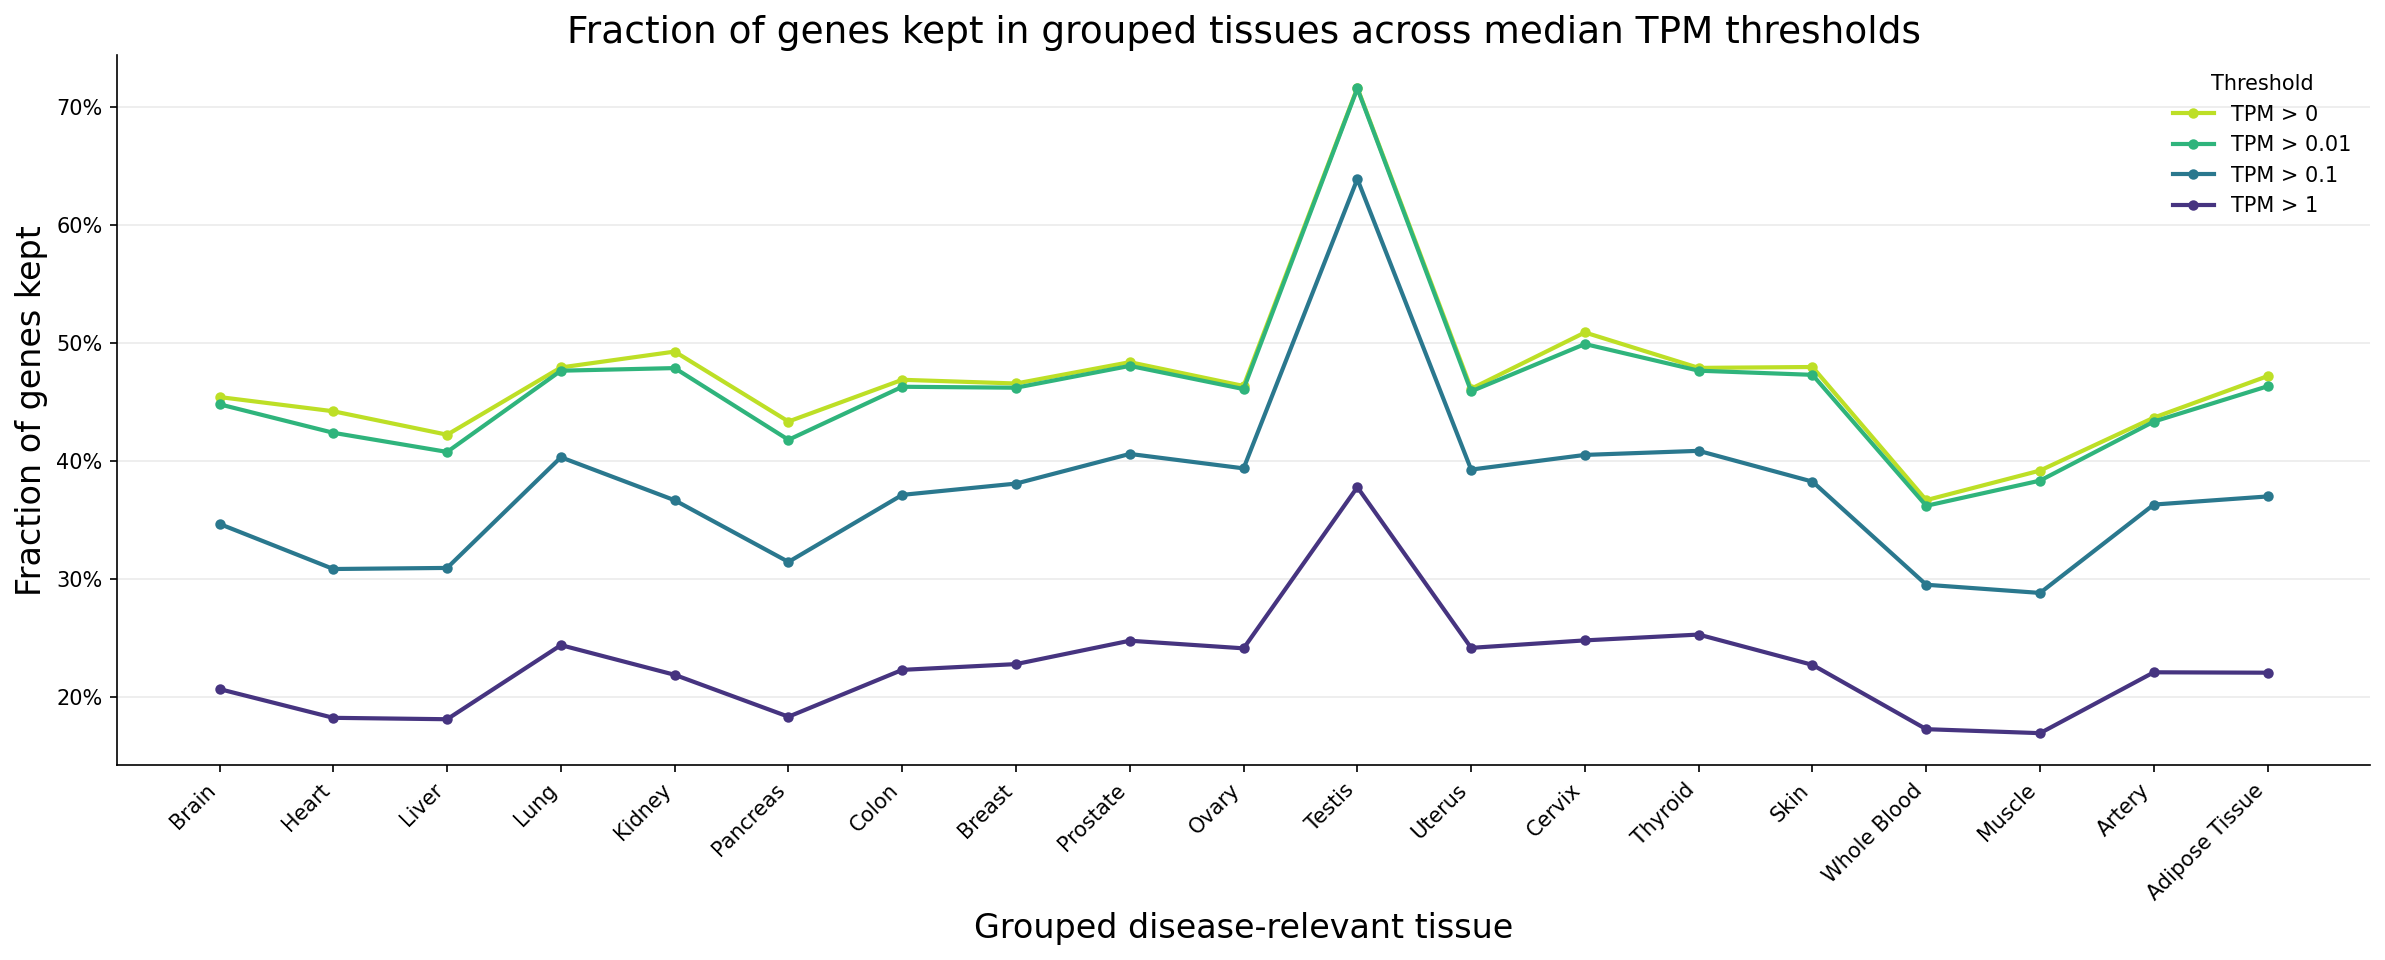

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

cutoffs = [0, 0.01, 0.1, 1]
tissue_columns = matched_tissues['median_tpm_tissue']
total_genes = len(median_tpm_by_tissue)

def parent_tissue_name(tissue_column):
    parent_name_overrides = {
        'Adipose': 'Adipose Tissue',
        'Adrenal': 'Adrenal Gland',
        'Fallopian': 'Fallopian Tube',
        'Minor': 'Minor Salivary Gland',
        'Small': 'Small Intestine',
        'Whole': 'Whole Blood',
    }
    parent = tissue_column.split('_')[0]
    return parent_name_overrides.get(parent, parent)

tissue_groups = tissue_columns.map(parent_tissue_name)
all_grouped_tissues = tissue_groups.drop_duplicates().to_list()

# Disease-focused tissues: broad organs with many well-characterized tissue-specific diseases.
disease_focused_tissues = [
    'Brain',
    'Heart',
    'Liver',
    'Lung',
    'Kidney',
    'Pancreas',
    'Colon',
    'Breast',
    'Prostate',
    'Ovary',
    'Testis',
    'Uterus',
    'Cervix',
    'Thyroid',
    'Skin',
    'Whole Blood',
    'Muscle',
    'Artery',
    'Adipose Tissue',
]
plot_order = [tissue for tissue in disease_focused_tissues if tissue in all_grouped_tissues]

# For each gene, collapse sub-tissues into one parent tissue by median TPM.
grouped_median_tpm = (
    median_tpm_by_tissue.loc[:, tissue_columns]
    .apply(pd.to_numeric, errors='coerce')
    .T
    .groupby(tissue_groups.to_numpy())
    .median()
    .T
    .loc[:, plot_order]
)

fractions_by_cutoff = {
    cutoff: (grouped_median_tpm > cutoff).sum(axis=0) / total_genes
    for cutoff in cutoffs
}

grouped_sample_sizes = (
    matched_tissues.assign(tissue_group=matched_tissues['median_tpm_tissue'].map(parent_tissue_name))
    .groupby('tissue_group', sort=False)['sample_size']
    .sum()
    .reindex(plot_order)
)
low_sample_size = grouped_sample_sizes < 100

fig, ax = plt.subplots(figsize=(16, 6.5), dpi=150)
colors = plt.cm.viridis_r([0.1 + 0.75 * i / max(len(cutoffs) - 1, 1) for i in range(len(cutoffs))])
x_positions = range(len(plot_order))

for color, cutoff in zip(colors, cutoffs):
    ax.plot(
        x_positions,
        fractions_by_cutoff[cutoff].loc[plot_order].values,
        linewidth=2.0,
        marker='o',
        markersize=4.0,
        color=color,
        label=f'TPM > {cutoff}',
    )

ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_order, rotation=45, ha='right')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Grouped disease-relevant tissue', fontsize=16)
ax.set_ylabel('Fraction of genes kept', fontsize=16)
ax.set_title('Fraction of genes kept in grouped tissues across median TPM thresholds', fontsize=18)


ax.legend(title='Threshold', loc='upper right', frameon=False)

print('Grouped disease-focused tissues included:')
print(plot_order)
print('\nGrouped tissues with sample size < 100:')
print(grouped_sample_sizes[low_sample_size])

plt.tight_layout()
plt.show()


In [5]:
from pathlib import Path
import sys

# Apply the same filtering logic as diseasemodulediscovery/bin/tissue_specific_filtering.py.
# This cell needs graph_tool, so run it in an environment where the pipeline can load .gt files.
try:
    import graph_tool.all as gt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "graph_tool is required to create filtered .gt networks. "
        "The next cell can still plot already-created filtering statistics."
    ) from exc

sys.path.insert(0, str(Path("diseasemodulediscovery/bin").resolve()))
import util as utils

network_filter_threshold = 0.1
filter_tissues = [
    "Brain_Hippocampus",
    "Heart_Atrial_Appendage",
    "Liver",
    "Lung",
    "Kidney_Cortex",
    "Pancreas",
]
network_files = sorted(Path("data/networks").glob("*.Ensembl.gt"))
filtered_output_dir = Path("filtered_networks_threshold_0.1")
filtered_output_dir.mkdir(exist_ok=True)

expression_wide = median_tpm_by_tissue.copy()
expression_wide["Name"] = expression_wide["Name"].astype(str).str.split(".", regex=False).str[0]

filtering_rows = []

for network_file in network_files:
    original_network = gt.load_graph(str(network_file))
    name_index = utils.name2index(original_network)
    network_num_vertices = original_network.num_vertices()

    for tissue in filter_tissues:
        expression_by_tissue = (
            expression_wide[["Name", tissue]]
            .rename(columns={tissue: "expression"})
            .copy()
        )
        expression_by_tissue["expression"] = pd.to_numeric(expression_by_tissue["expression"], errors="coerce").fillna(0)
        expression_num_entries = expression_by_tissue.shape[0]
        in_network_expression = expression_by_tissue[expression_by_tissue["Name"].isin(name_index)].copy()
        tissue_specific_in_network = in_network_expression[
            in_network_expression["expression"] > network_filter_threshold
        ].copy()

        genes_not_in_network = expression_num_entries - in_network_expression.shape[0]
        genes_not_in_expression_file = network_num_vertices - in_network_expression["Name"].nunique()
        genes_filtered_by_threshold = in_network_expression.shape[0] - tissue_specific_in_network.shape[0]

        network = gt.load_graph(str(network_file))
        tissue_specific_in_network["vertex_id"] = tissue_specific_in_network["Name"].map(name_index)
        tissue_filter = f"{tissue}_filter"
        network.vp[tissue_filter] = network.new_vertex_property("bool")
        for vertex_id in tissue_specific_in_network["vertex_id"].dropna().astype(int).unique():
            network.vp[tissue_filter][vertex_id] = True
        network.set_vertex_filter(network.vp[tissue_filter])
        network.purge_vertices()
        network.clear_filters()
        del network.vp[tissue_filter]
        network.save(str(filtered_output_dir / f"{network_file.stem}.{tissue}.gt"))

        filtering_rows.append({
            "network": f"{network_file.stem}.{tissue}",
            "base_network": network_file.stem,
            "tissue": tissue,
            "genes_in_tissue": int((expression_by_tissue["expression"] > network_filter_threshold).sum()),
            "genes_not_in_network_absolute": int(genes_not_in_network),
            "genes_not_in_network_relative": genes_not_in_network / expression_num_entries if expression_num_entries else 0.0,
            "genes_not_in_expression_file_absolute": int(genes_not_in_expression_file),
            "genes_not_in_expression_file_relative": genes_not_in_expression_file / network_num_vertices if network_num_vertices else 0.0,
            "genes_filtered_by_threshold_absolute": int(genes_filtered_by_threshold),
            "genes_filtered_by_threshold_relative": genes_filtered_by_threshold / network_num_vertices if network_num_vertices else 0.0,
        })

filtering_statistics = pd.DataFrame(filtering_rows)
filtering_statistics.to_csv(filtered_output_dir / "filtering_statistics_threshold_0.1.tsv", sep="	", index=False)
filtering_statistics


,network,base_network,tissue,genes_in_tissue,genes_not_in_network_absolute,genes_not_in_network_relative,genes_not_in_expression_file_absolute,genes_not_in_expression_file_relative,genes_filtered_by_threshold_absolute,genes_filtered_by_threshold_relative
0,biogrid.4_4_242_homo_sapiens.Ensembl.Brain_Hip...,biogrid.4_4_242_homo_sapiens.Ensembl,Brain_Hippocampus,25478,56765,0.760639,2053,0.103083,2678,0.134465
1,biogrid.4_4_242_homo_sapiens.Ensembl.Heart_Atr...,biogrid.4_4_242_homo_sapiens.Ensembl,Heart_Atrial_Appendage,24215,56765,0.760639,2053,0.103083,3281,0.164742
2,biogrid.4_4_242_homo_sapiens.Ensembl.Liver,biogrid.4_4_242_homo_sapiens.Ensembl,Liver,23101,56765,0.760639,2053,0.103083,3561,0.178801
3,biogrid.4_4_242_homo_sapiens.Ensembl.Lung,biogrid.4_4_242_homo_sapiens.Ensembl,Lung,30082,56765,0.760639,2053,0.103083,2248,0.112874
4,biogrid.4_4_242_homo_sapiens.Ensembl.Kidney_Co...,biogrid.4_4_242_homo_sapiens.Ensembl,Kidney_Cortex,25694,56765,0.760639,2053,0.103083,2780,0.139586
5,biogrid.4_4_242_homo_sapiens.Ensembl.Pancreas,biogrid.4_4_242_homo_sapiens.Ensembl,Pancreas,23287,56765,0.760639,2053,0.103083,3319,0.166650
6,hippie.v2_3_high_confidence.Ensembl.Brain_Hipp...,hippie.v2_3_high_confidence.Ensembl,Brain_Hippocampus,25478,61478,0.823793,1520,0.103613,1421,0.096864
7,hippie.v2_3_high_confidence.Ensembl.Heart_Atri...,hippie.v2_3_high_confidence.Ensembl,Heart_Atrial_Appendage,24215,61478,0.823793,1520,0.103613,1723,0.117451
8,hippie.v2_3_high_confidence.Ensembl.Liver,hippie.v2_3_high_confidence.Ensembl,Liver,23101,61478,0.823793,1520,0.103613,1905,0.129857
9,hippie.v2_3_high_confidence.Ensembl.Lung,hippie.v2_3_high_confidence.Ensembl,Lung,30082,61478,0.823793,1520,0.103613,1111,0.075733


,threshold,base_network,tissue,genes_in_tissue,genes_filtered_by_threshold_absolute,genes_filtered_by_threshold_fraction,genes_not_in_network_absolute,genes_not_in_network_fraction,genes_not_in_expression_file_absolute,genes_not_in_expression_file_relative
0,0.01,iid.human.Symbol,Brain_Hippocampus,22501,1669,0.091058,21143,0.537908,166,0.009057
1,0.01,string.human_links_v12_0_min900.Symbol,Brain_Hippocampus,22501,820,0.068752,27477,0.699054,98,0.008217
3,0.10,iid.human.Symbol,Brain_Hippocampus,19182,2878,0.157019,21143,0.537908,166,0.009057
2,0.10,string.human_links_v12_0_min900.Symbol,Brain_Hippocampus,19182,1506,0.126268,27477,0.699054,98,0.008217
5,1.00,iid.human.Symbol,Brain_Hippocampus,13862,5454,0.297561,21143,0.537908,166,0.009057
4,1.00,string.human_links_v12_0_min900.Symbol,Brain_Hippocampus,13862,3055,0.256142,27477,0.699054,98,0.008217


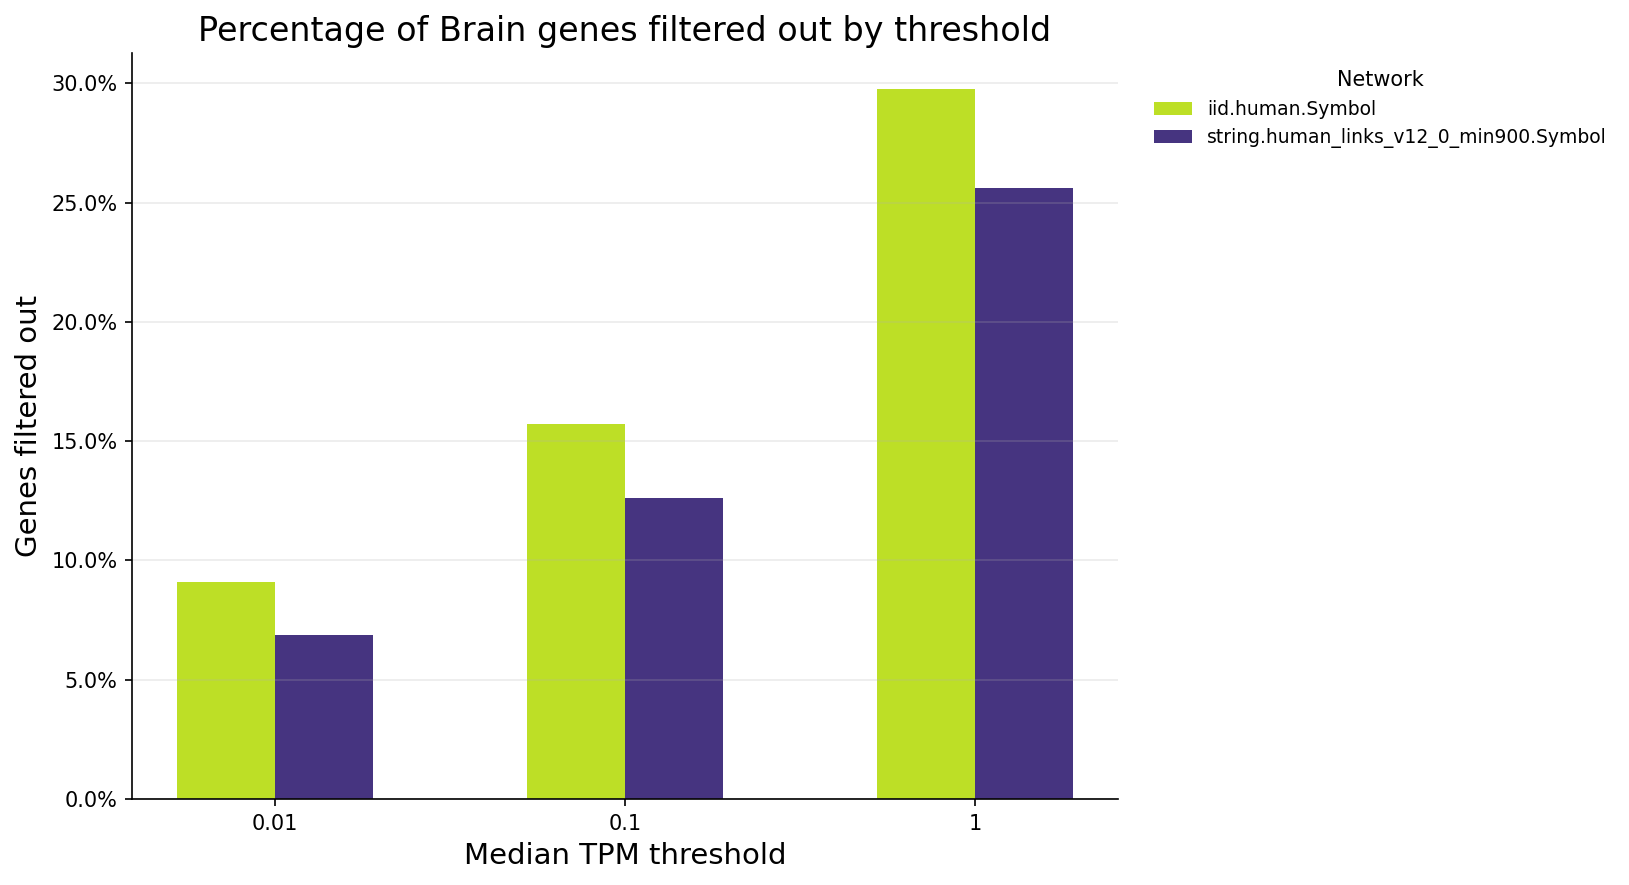

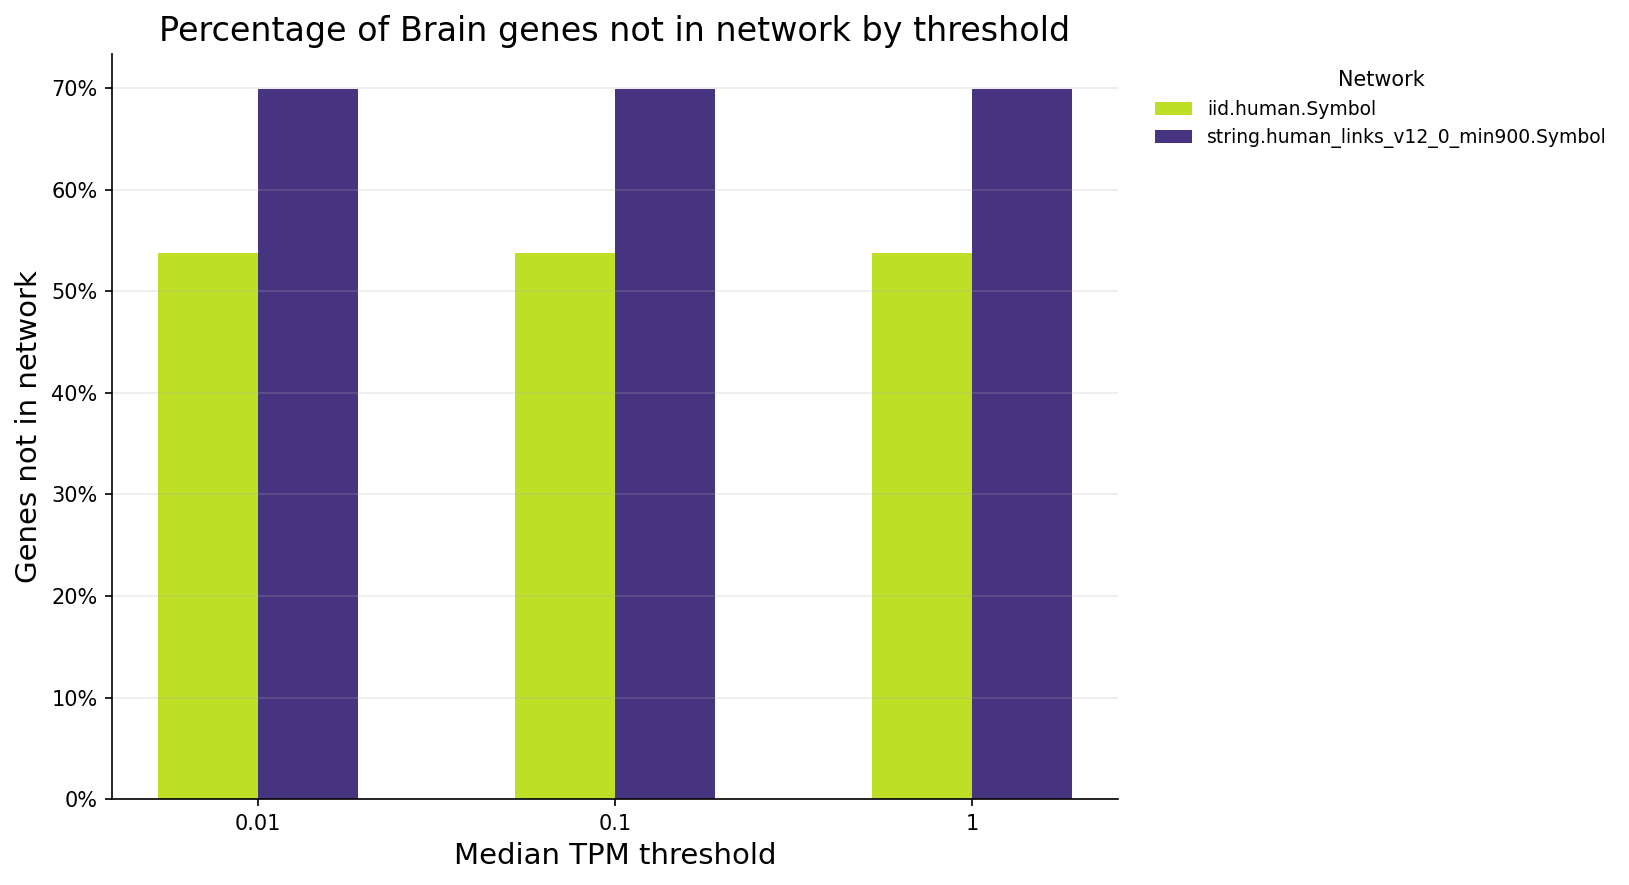

In [6]:
from pathlib import Path
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

target_tissue = "Brain_Hippocampus"
target_tissue_label = "Brain"

def threshold_from_path(path):
    match = re.search(r"threshold_([0-9.]+)", str(path))
    return float(match.group(1)) if match else None

stats_paths = sorted(
    Path(".").glob("alzheimer_run_symbol_threshold_*/mqc_summaries/filtering_statistics_mqc.tsv"),
    key=lambda path: threshold_from_path(path) if threshold_from_path(path) is not None else float("inf"),
)
if not stats_paths:
    stats_paths = [
        Path("filtered_networks_threshold_0.1/filtering_statistics_threshold_0.1.tsv"),
        Path("diseasemodulediscovery/results/mqc_summaries/filtering_statistics_mqc.tsv"),
        Path("alzheimer_run_symbol_threshold_0.1/mqc_summaries/filtering_statistics_mqc.tsv"),
    ]
    stats_paths = [path for path in stats_paths if path.exists()]
if not stats_paths:
    raise FileNotFoundError("No filtering statistics table found. Run the filtering cell or the pipeline first.")

stats_tables = []
for stats_path in stats_paths:
    threshold = threshold_from_path(stats_path)
    if threshold is None:
        continue
    stats_table = pd.read_csv(stats_path, sep="\t")
    stats_table["threshold"] = threshold
    stats_tables.append(stats_table)
if not stats_tables:
    raise ValueError("Could not infer threshold values from the filtering statistics paths.")

filtering_statistics = pd.concat(stats_tables, ignore_index=True)
filtering_statistics["tissue"] = (
    filtering_statistics["tissue"]
    .astype(str)
    .str.extract(r">([^<>]+)</a>", expand=False)
    .fillna(filtering_statistics["tissue"].astype(str))
)

if "base_network" not in filtering_statistics.columns:
    tissues_by_length = sorted(filtering_statistics["tissue"].dropna().unique(), key=len, reverse=True)
    def strip_tissue_suffix(network_name):
        for tissue in tissues_by_length:
            suffix = f".{tissue}"
            if str(network_name).endswith(suffix):
                return str(network_name)[:-len(suffix)]
        return network_name
    filtering_statistics["base_network"] = filtering_statistics["network"].map(strip_tissue_suffix)

filtering_statistics["genes_filtered_by_threshold_fraction"] = filtering_statistics[
    "genes_filtered_by_threshold_relative"
]
filtering_statistics["genes_not_in_network_fraction"] = filtering_statistics[
    "genes_not_in_network_relative"
]

plot_stats = (
    filtering_statistics[filtering_statistics["tissue"] == target_tissue]
    .sort_values(["threshold", "base_network"])
    .copy()
)
if plot_stats.empty:
    available_tissues = ", ".join(sorted(filtering_statistics["tissue"].dropna().unique()))
    raise ValueError(f"No rows found for {target_tissue}. Available tissues: {available_tissues}")

display_columns = [
    "threshold",
    "base_network",
    "tissue",
    "genes_in_tissue",
    "genes_filtered_by_threshold_absolute",
    "genes_filtered_by_threshold_fraction",
    "genes_not_in_network_absolute",
    "genes_not_in_network_fraction",
    "genes_not_in_expression_file_absolute",
    "genes_not_in_expression_file_relative",
]
display(plot_stats[display_columns])

threshold_order = sorted(plot_stats["threshold"].dropna().unique())
threshold_labels = [f"{threshold:g}" for threshold in threshold_order]
network_order = (
    plot_stats.groupby("base_network")["genes_filtered_by_threshold_fraction"]
    .mean()
    .sort_values(ascending=False)
    .index
    .to_list()
)
colors = plt.cm.viridis_r([0.1 + 0.75 * i / max(len(network_order) - 1, 1) for i in range(len(network_order))])
network_colors = dict(zip(network_order, colors))

def plot_filtering_fraction(metric_column, title, ylabel):
    metric_data = (
        plot_stats.pivot_table(
            index="threshold",
            columns="base_network",
            values=metric_column,
            aggfunc="mean",
        )
        .reindex(index=threshold_order, columns=network_order)
    )
    x_positions = list(range(len(threshold_order)))
    bar_width = min(0.8 / max(len(network_order), 1), 0.28)

    fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
    for idx, network in enumerate(network_order):
        offsets = [x + (idx - (len(network_order) - 1) / 2) * bar_width for x in x_positions]
        ax.bar(
            offsets,
            metric_data[network].values,
            width=bar_width,
            color=network_colors[network],
            label=network,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(threshold_labels)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Median TPM threshold", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(title="Network", loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

plot_filtering_fraction(
    "genes_filtered_by_threshold_fraction",
    f"Percentage of {target_tissue_label} genes filtered out by threshold",
    "Genes filtered out",
)
plot_filtering_fraction(
    "genes_not_in_network_fraction",
    f"Percentage of {target_tissue_label} genes not in network by threshold",
    "Genes not in network",
)


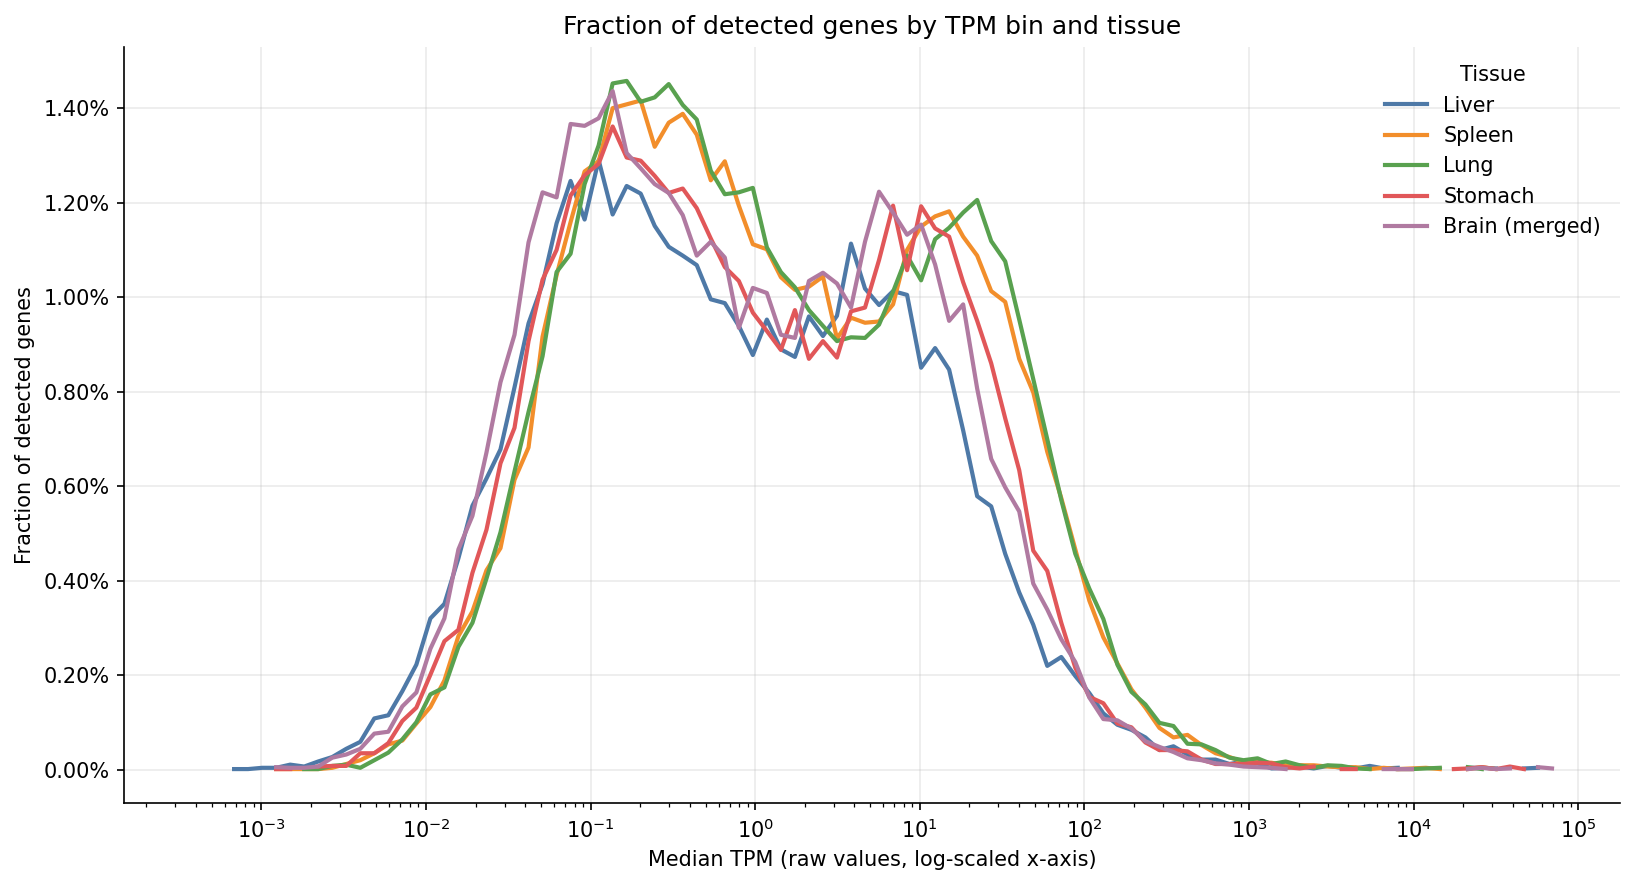

Merged brain tissues: 13 columns
['Brain_Amygdala', 'Brain_Anterior_cingulate_cortex_BA24', 'Brain_Caudate_basal_ganglia', 'Brain_Cerebellar_Hemisphere', 'Brain_Cerebellum', 'Brain_Cortex', 'Brain_Frontal_Cortex_BA9', 'Brain_Hippocampus', 'Brain_Hypothalamus', 'Brain_Nucleus_accumbens_basal_ganglia', 'Brain_Putamen_basal_ganglia', 'Brain_Spinal_cord_cervical_c-1', 'Brain_Substantia_nigra']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

selected_tissues = ["Liver", "Spleen", "Lung", "Stomach"]
brain_tissues = [col for col in median_tpm_by_tissue.columns if col.startswith("Brain_")] 

missing_tissues = [t for t in selected_tissues if t not in median_tpm_by_tissue.columns]
if missing_tissues:
    raise ValueError(f"Missing tissue columns in median_tpm_by_tissue: {missing_tissues}")
if not brain_tissues:
    raise ValueError("No brain tissues found (expected columns starting with 'Brain_').")

expression_df = median_tpm_by_tissue[selected_tissues].copy()
expression_df["Brain (merged)"] = median_tpm_by_tissue[brain_tissues].median(axis=1)

plot_order = ["Liver", "Spleen", "Lung", "Stomach", "Brain (merged)"]
colors = {
    "Liver": "#4e79a7",
    "Spleen": "#f28e2b",
    "Lung": "#59a14f",
    "Stomach": "#e15759",
    "Brain (merged)": "#b07aa1",
}

# Shared log-spaced bins on raw TPM values (positive only for log-scaled x-axis).
all_values = expression_df[plot_order].to_numpy().ravel()
all_values = all_values[(~np.isnan(all_values)) & (all_values > 0)]
if all_values.size == 0:
    raise ValueError("No positive TPM values available for log-scaled x-axis plot.")

vmin, vmax = all_values.min(), all_values.max()
if np.isclose(vmin, vmax):
    raise ValueError("TPM values are constant; cannot build a distribution curve.")

bin_edges = np.logspace(np.log10(vmin), np.log10(vmax), 100)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

for tissue in plot_order:
    values = expression_df[tissue].dropna().to_numpy()
    values = values[values > 0]
    if values.size == 0:
        continue

    counts, _ = np.histogram(values, bins=bin_edges, density=False)
    fractions = counts / 74628
    fractions = np.where(fractions <= 0, np.nan, fractions)
    ax.plot(bin_centers, fractions, label=tissue, color=colors[tissue], linewidth=2)



ax.set_title("Fraction of detected genes by TPM bin and tissue")
ax.set_xlabel("Median TPM (raw values, log-scaled x-axis)")
ax.set_ylabel("Fraction of detected genes")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Tissue", frameon=False)

plt.tight_layout()
plt.show()

print(f"Merged brain tissues: {len(brain_tissues)} columns")
print(brain_tissues)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

selected_tissues = ["Liver", "Spleen", "Lung", "Stomach","Testis"]
brain_tissues = [col for col in median_tpm_by_tissue.columns if col.startswith("Brain_")]

missing_tissues = [t for t in selected_tissues if t not in median_tpm_by_tissue.columns]
if missing_tissues:
    raise ValueError(f"Missing tissue columns in median_tpm_by_tissue: {missing_tissues}")
if not brain_tissues:
    raise ValueError("No brain tissues found (expected columns starting with 'Brain_').")

expression_df = median_tpm_by_tissue[selected_tissues].copy()
expression_df["Brain (merged)"] = median_tpm_by_tissue[brain_tissues].median(axis=1)

plot_order = ["Liver", "Spleen", "Lung", "Stomach", "Brain (merged)"]
colors = {
    "Liver": "#4e79a7",
    "Spleen": "#f28e2b",
    "Lung": "#59a14f",
    "Stomach": "#e15759",
    "Brain (merged)": "#b07aa1",
    "Testis": "#0DB6E0"
}

fig, ax = plt.subplots(figsize=(12, 6), dpi=400)

for tissue in plot_order:
    values = expression_df[tissue].dropna().to_numpy()
    values = values[values > 0]
    if values.size == 0:
        continue

    values_sorted = np.sort(values)
    y = np.arange(1, values_sorted.size + 1) / values_sorted.size
    ax.plot(values_sorted, y, label=tissue, color=colors[tissue], linewidth=2)

ax.set_title("Cumulative distribution of median TPM values of selected tissues", fontsize = 18)
ax.set_xlabel("Median TPM (raw values, log-scaled x-axis)", fontsize=16)
ax.set_ylabel("Cumulative fraction of detected genes", fontsize=16)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Tissue", frameon=False)

# Add vertical threshold lines at TPM = 0.01, 0.1, 1
for _thr in [0.01, 0.1, 1]:
    try:
        ax.axvline(_thr, color='red', linestyle='--', linewidth=1, alpha=0.8)
    except Exception:
        pass


plt.show()


NameError: name 'median_tpm_by_tissue' is not defined

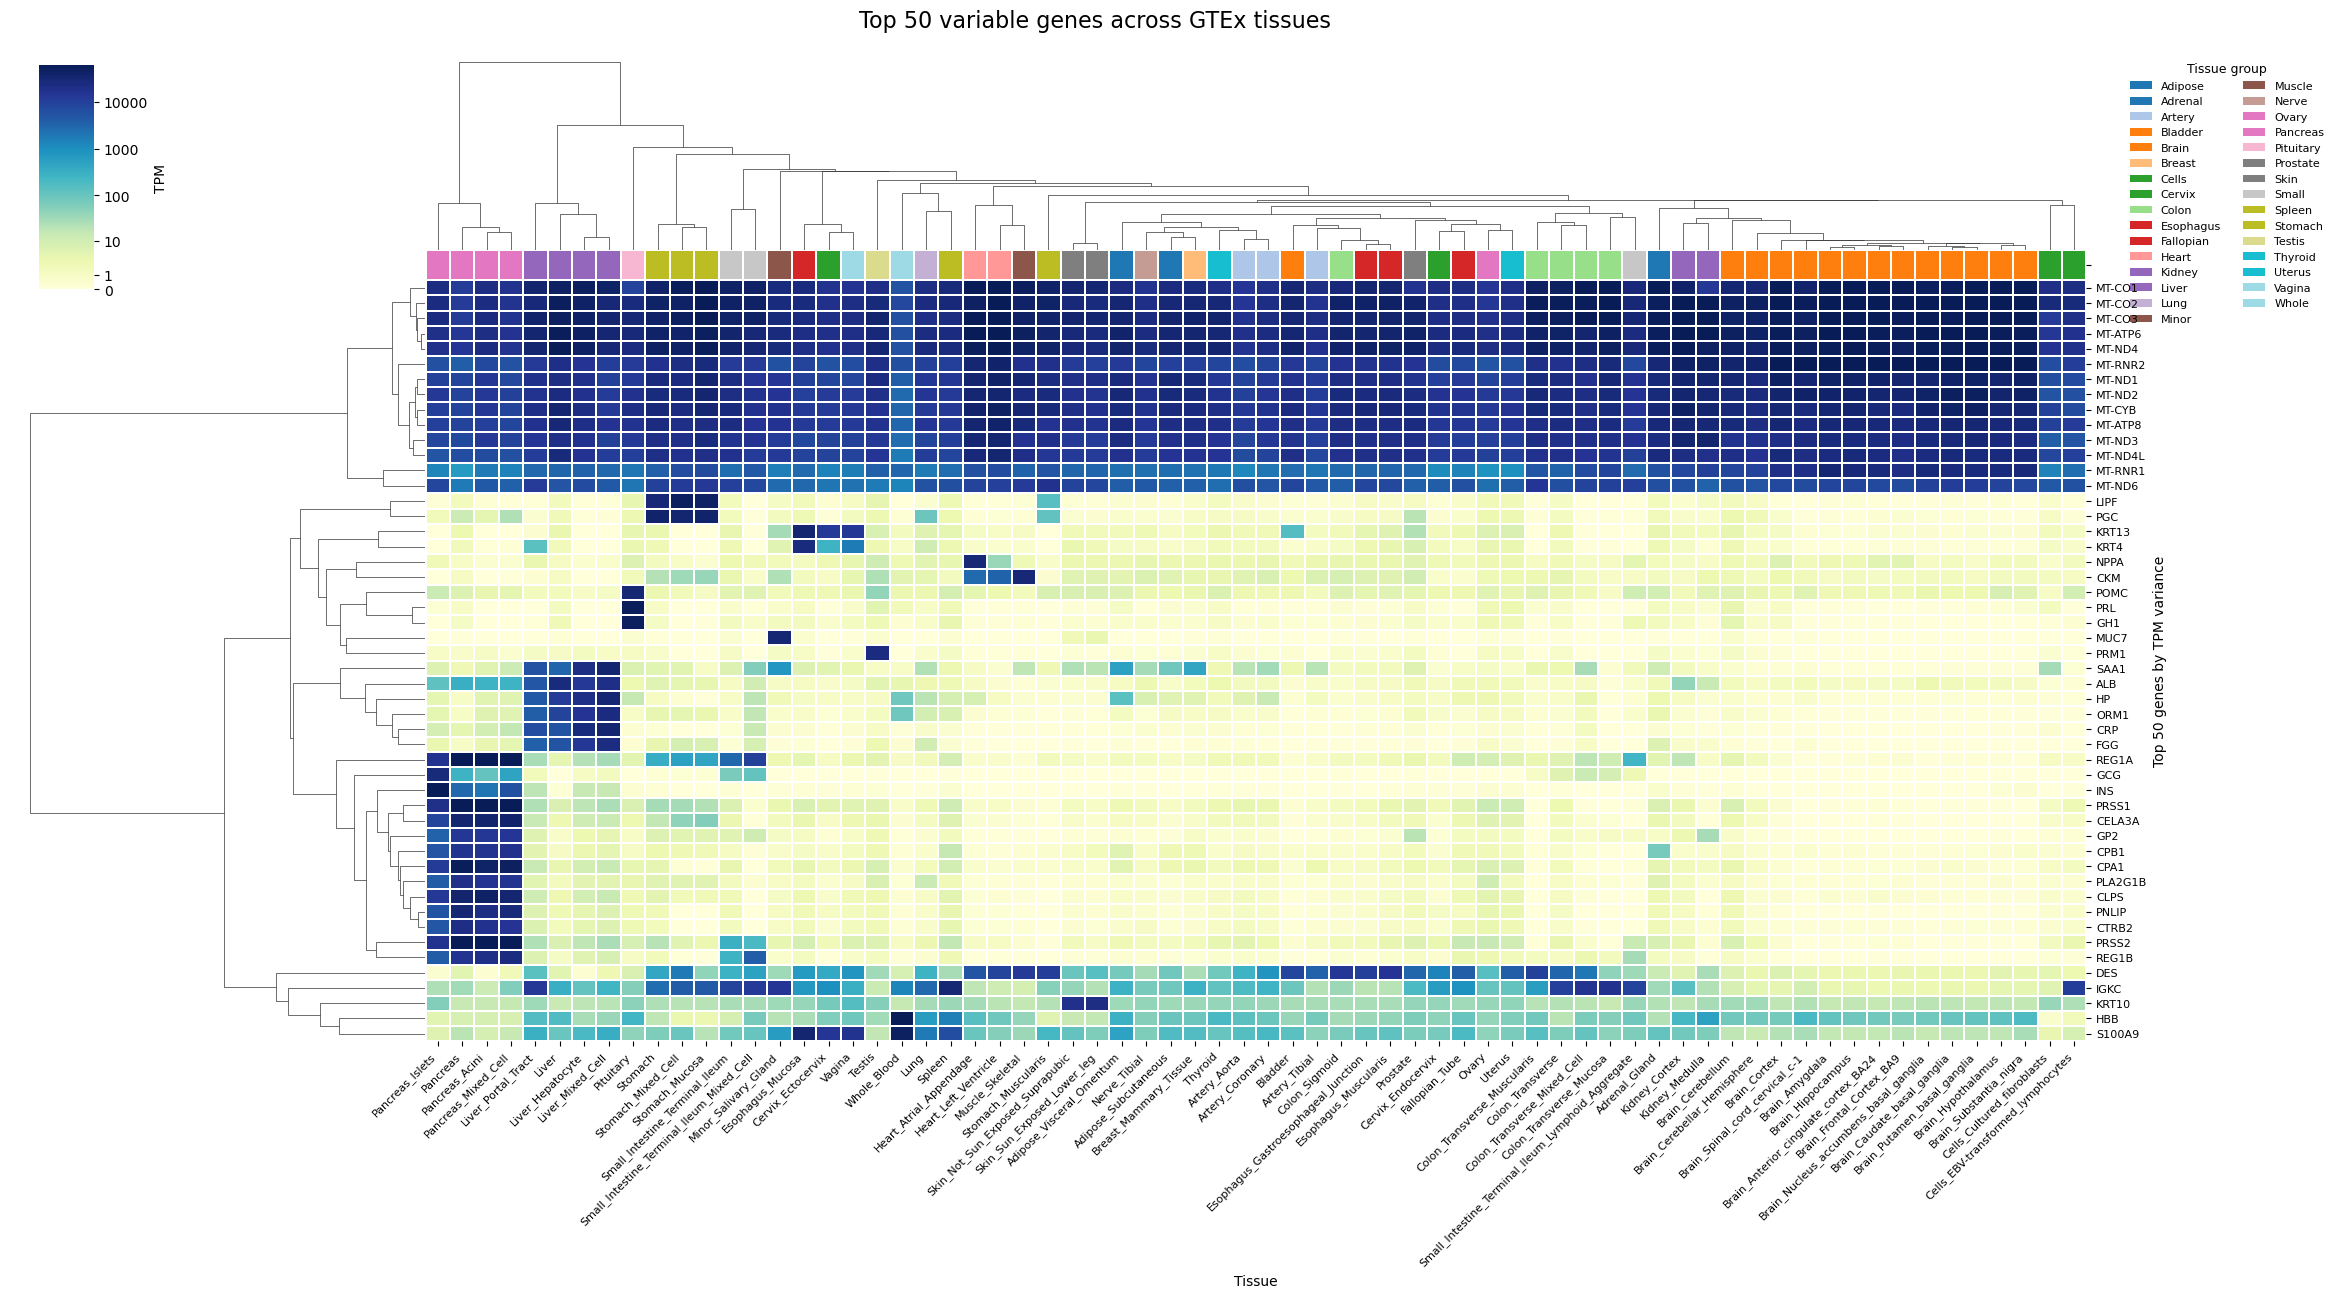

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

top_n = 50
tissue_columns = median_tpm_by_tissue.columns[2:]

expression_matrix = (
    median_tpm_by_tissue.loc[:, tissue_columns]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

top_variable_gene_idx = expression_matrix.var(axis=1).nlargest(top_n).index
top_variable_tpm = expression_matrix.loc[top_variable_gene_idx].copy()
gene_labels = median_tpm_by_tissue.loc[top_variable_gene_idx, 'Description'].fillna(
    median_tpm_by_tissue.loc[top_variable_gene_idx, 'Name']
)
top_variable_tpm.index = gene_labels

tissue_groups = pd.Index(top_variable_tpm.columns).str.split('_').str[0]
groups = tissue_groups.unique()
group_palette = dict(zip(groups, plt.cm.tab20(np.linspace(0, 1, len(groups)))))
col_colors = pd.Series([group_palette[group] for group in tissue_groups], index=top_variable_tpm.columns)

plot_tpm = np.log10(top_variable_tpm + 1)
vmax = np.nanpercentile(plot_tpm.to_numpy(), 98)
tpm_ticks = np.array([0, 1, 10, 100, 1000, 10000])
visible_tpm_ticks = tpm_ticks[np.log10(tpm_ticks + 1) <= vmax]

cluster_grid = sns.clustermap(
    plot_tpm,
    cmap='YlGnBu',
    vmin=0,
    vmax=vmax,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.25,
    linecolor='white',
    figsize=(24, 14),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'TPM'},
    cbar_pos=(0.02, 0.82, 0.025, 0.16),
)

cluster_grid.fig.subplots_adjust(right=0.82)
cluster_grid.fig.suptitle('Top 50 variable genes across GTEx tissues', y=1.02, fontsize=16)

cluster_grid.ax_heatmap.set_xlabel('Tissue')
cluster_grid.ax_heatmap.set_ylabel('Top 50 genes by TPM variance')
cluster_grid.ax_heatmap.set_xticklabels(
    cluster_grid.ax_heatmap.get_xticklabels(), rotation=60, ha='right', fontsize=7, rotation_mode='anchor'
)
cluster_grid.ax_heatmap.set_yticklabels(cluster_grid.ax_heatmap.get_yticklabels(), fontsize=7)

cluster_grid.cax.set_yticks(np.log10(visible_tpm_ticks + 1))
cluster_grid.cax.set_yticklabels([f'{tick:g}' for tick in visible_tpm_ticks])

legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markerfacecolor=group_palette[group],
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=7,
        label=group,
    )
    for group in groups
]
cluster_grid.fig.legend(
    handles=legend_handles,
    title='Tissue group',
    bbox_to_anchor=(0.985, 0.94),
    loc='upper left',
    frameon=False,
    ncol=1,
    fontsize=8,
    title_fontsize=9,
)

plt.show()

Filtered out 37 mitochondrial genes before selecting top 50.


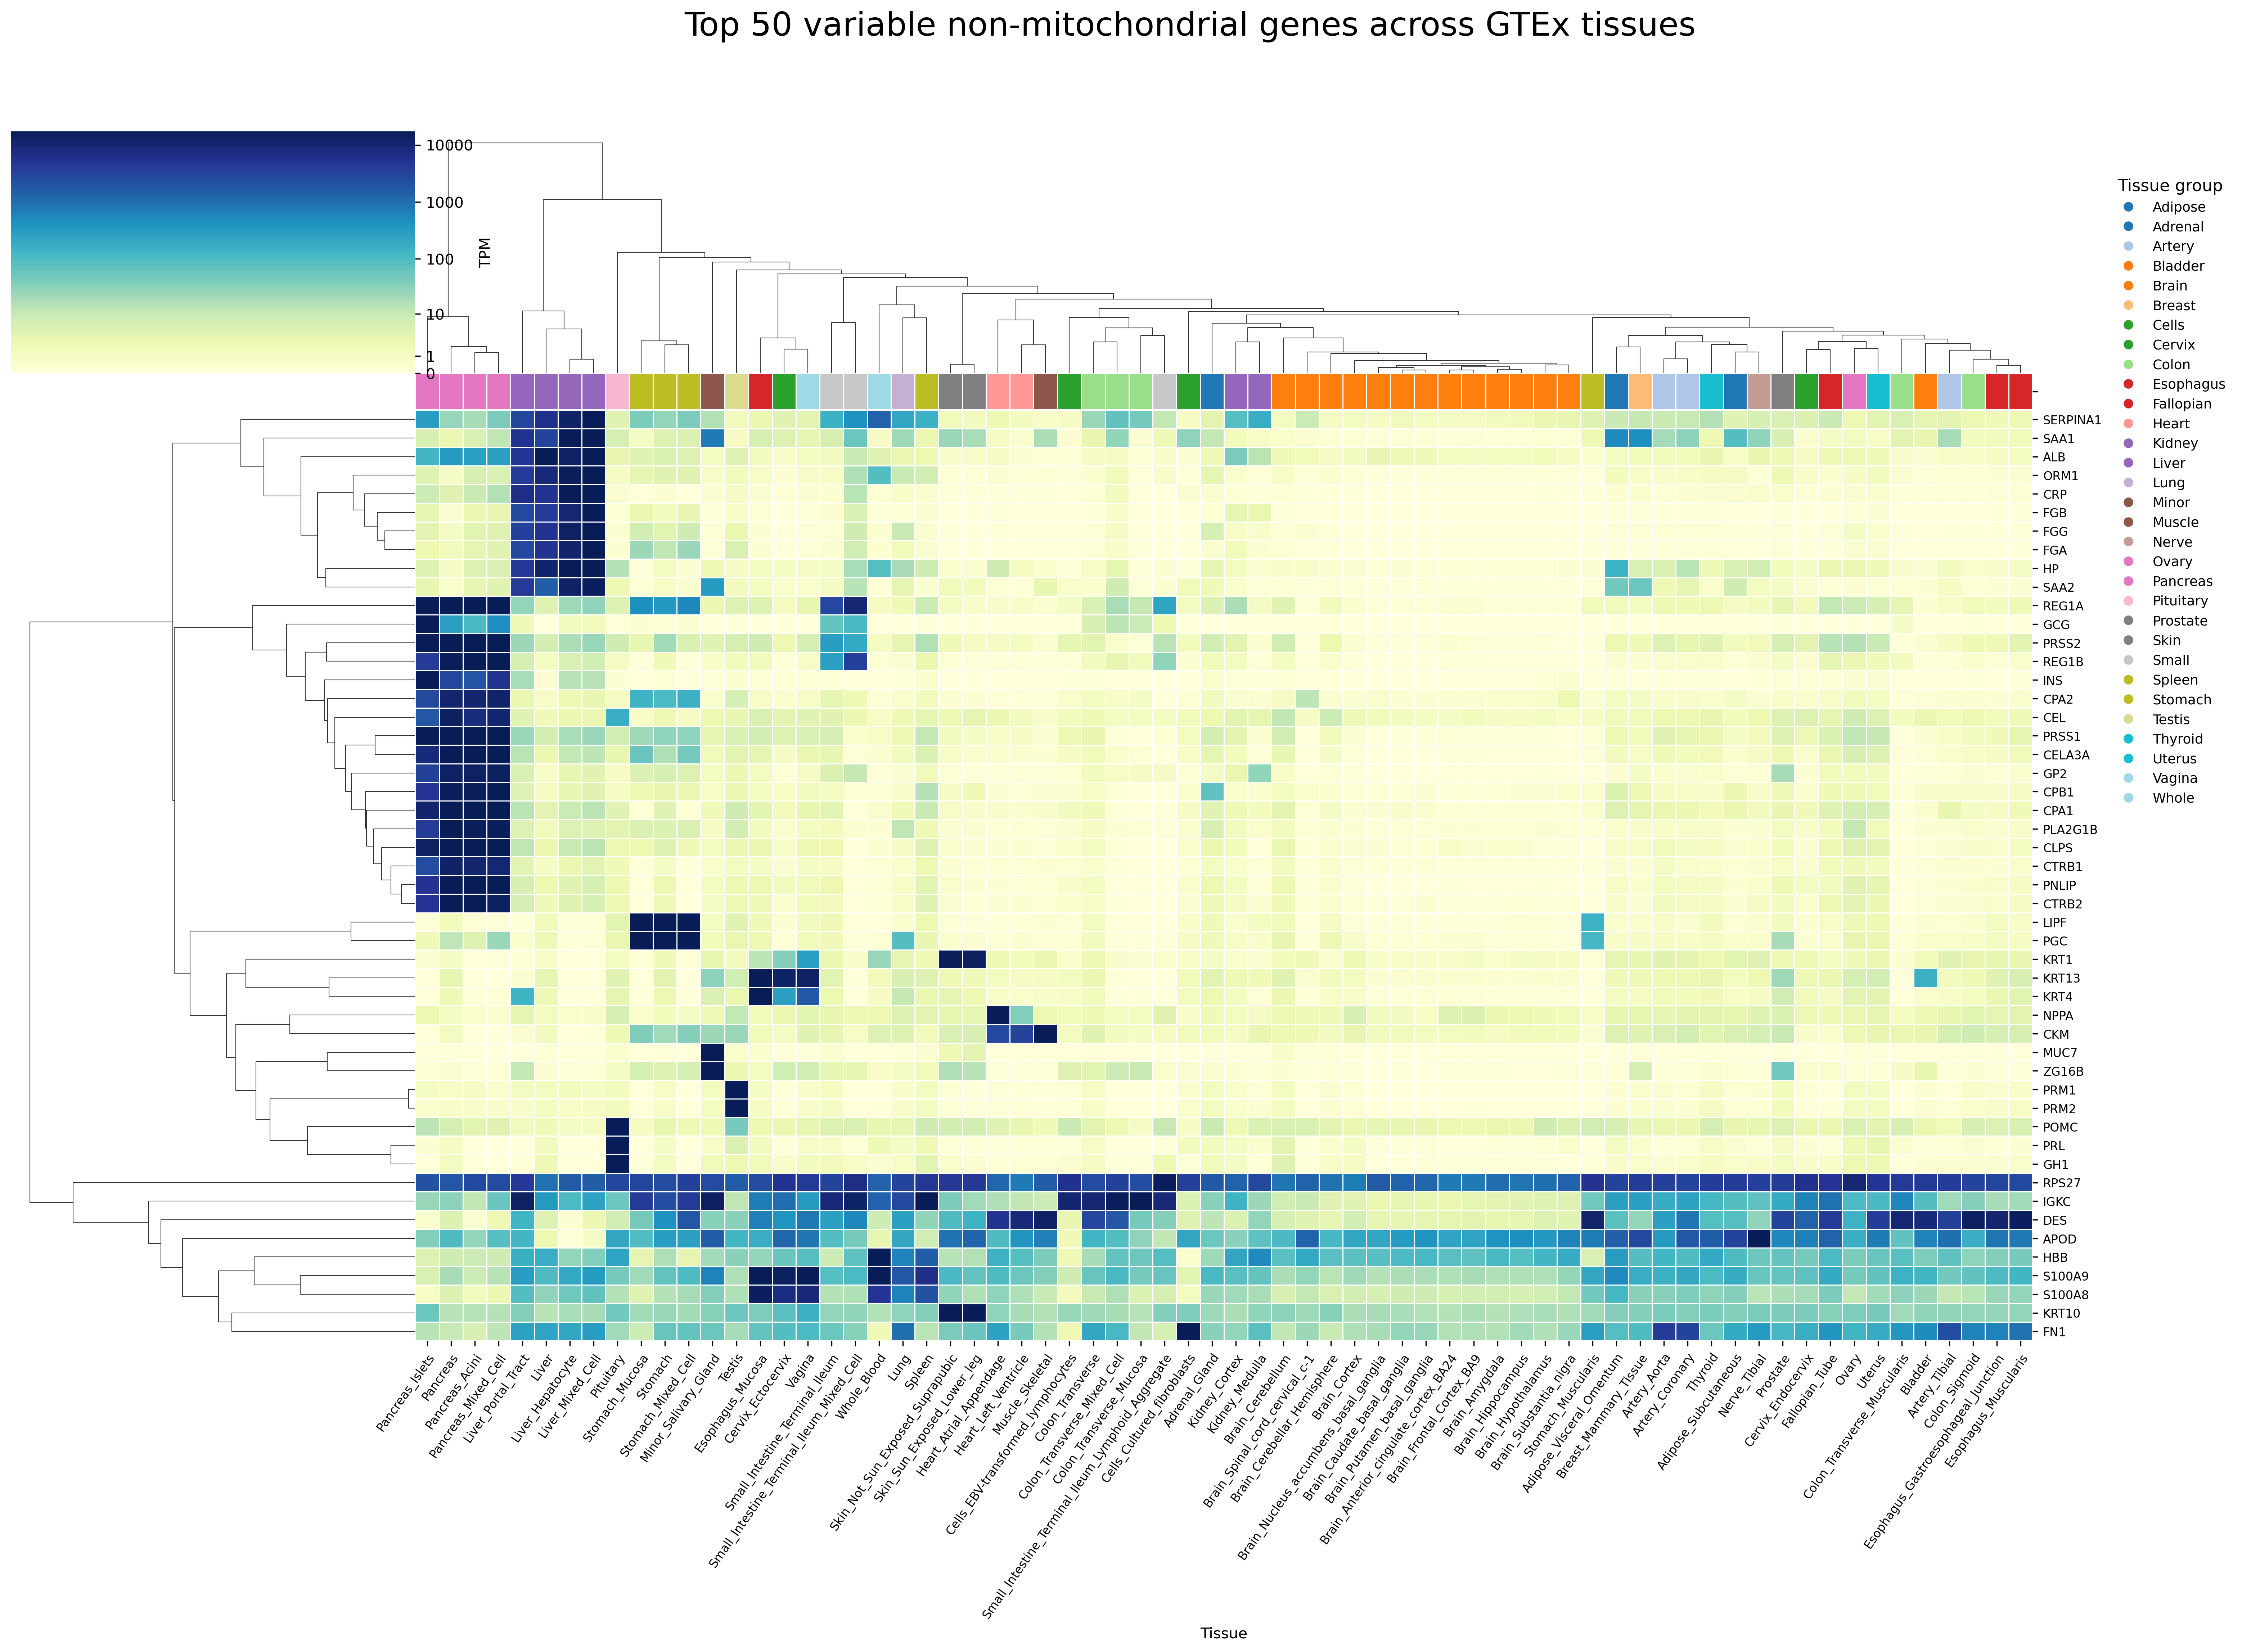

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

top_n = 50
tissue_columns = median_tpm_by_tissue.columns[2:]

gene_symbols = median_tpm_by_tissue['Description'].fillna('').astype(str)
gene_ids = median_tpm_by_tissue['Name'].fillna('').astype(str)
mitochondrial_genes = gene_symbols.str.startswith('MT-') | gene_ids.str.startswith('ENSGM')

expression_matrix_no_mito = (
    median_tpm_by_tissue.loc[~mitochondrial_genes, tissue_columns]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

top_variable_gene_idx_no_mito = expression_matrix_no_mito.var(axis=1).nlargest(top_n).index
top_variable_tpm_no_mito = expression_matrix_no_mito.loc[top_variable_gene_idx_no_mito].copy()
gene_labels_no_mito = median_tpm_by_tissue.loc[top_variable_gene_idx_no_mito, 'Description'].fillna(
    median_tpm_by_tissue.loc[top_variable_gene_idx_no_mito, 'Name']
)
top_variable_tpm_no_mito.index = gene_labels_no_mito

tissue_groups = pd.Index(top_variable_tpm_no_mito.columns).str.split('_').str[0]
groups = tissue_groups.unique()
group_palette = dict(zip(groups, plt.cm.tab20(np.linspace(0, 1, len(groups)))))
col_colors = pd.Series([group_palette[group] for group in tissue_groups], index=top_variable_tpm_no_mito.columns)

plot_tpm_no_mito = np.log10(top_variable_tpm_no_mito + 1)
vmax = np.nanpercentile(plot_tpm_no_mito.to_numpy(), 98)
tpm_ticks = np.array([0, 1, 10, 100, 1000, 10000])
visible_tpm_ticks = tpm_ticks[np.log10(tpm_ticks + 1) <= vmax]

cluster_grid = sns.clustermap(
    plot_tpm_no_mito,
    cmap='YlGnBu',
    vmin=0,
    vmax=vmax,
    col_colors=col_colors,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.25,
    linecolor='white',
    figsize=(26, 16),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'TPM'},
    cbar_pos=(0.03, 0.78, 0.018, 0.12),
)

cluster_grid.fig.set_dpi(300)
cluster_grid.fig.subplots_adjust(left=0.08, right=0.80, bottom=0.20, top=0.90)
cluster_grid.fig.suptitle('Top 50 variable non-mitochondrial genes across GTEx tissues', y=0.97, fontsize=22)

cluster_grid.ax_heatmap.set_xlabel('Tissue')
cluster_grid.ax_heatmap.set_ylabel('')
cluster_grid.ax_heatmap.set_xticklabels(
    cluster_grid.ax_heatmap.get_xticklabels(), rotation=55, ha='right', fontsize=8, rotation_mode='anchor'
)
cluster_grid.ax_heatmap.set_yticklabels(cluster_grid.ax_heatmap.get_yticklabels(), fontsize=8)

cluster_grid.cax.set_yticks(np.log10(visible_tpm_ticks + 1))
cluster_grid.cax.set_yticklabels([f'{tick:g}' for tick in visible_tpm_ticks])

legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markerfacecolor=group_palette[group],
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=7,
        label=group,
    )
    for group in groups
]
cluster_grid.fig.legend(
    handles=legend_handles,
    title='Tissue group',
    bbox_to_anchor=(0.825, 0.88),
    loc='upper left',
    frameon=False,
    ncol=1,
    fontsize=9,
    title_fontsize=11,
)

print(f'Filtered out {mitochondrial_genes.sum()} mitochondrial genes before selecting top {top_n}.')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import to_rgba_array
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from sklearn.decomposition import PCA
from adjustText import adjust_text

# Shared tissue-group colors
top_n = 50
tissue_columns = median_tpm_by_tissue.columns[2:]
def parent_tissue_name(tissue_column):
    parent_name_overrides = {
        'Adipose': 'Adipose Tissue',
        'Adrenal': 'Adrenal Gland',
        'Fallopian': 'Fallopian Tube',
        'Minor': 'Minor Salivary Gland',
        'Small': 'Small Intestine',
        'Whole': 'Whole Blood',
    }
    parent = tissue_column.split('_')[0]
    return parent_name_overrides.get(parent, parent)

tissue_groups = pd.Index(tissue_columns).map(parent_tissue_name)
groups = tissue_groups.unique()
group_palette = dict(zip(groups, plt.cm.tab20(np.linspace(0, 1, len(groups)))))
column_colors = pd.Series([group_palette[group] for group in tissue_groups], index=tissue_columns)

# Non-mitochondrial top-variable gene heatmap data
gene_symbols = median_tpm_by_tissue['Description'].fillna('').astype(str)
gene_ids = median_tpm_by_tissue['Name'].fillna('').astype(str)
mitochondrial_genes = gene_symbols.str.startswith('MT-') | gene_ids.str.startswith('ENSGM')

expression_matrix_no_mito = (
    median_tpm_by_tissue.loc[~mitochondrial_genes, tissue_columns]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

top_variable_gene_idx_no_mito = expression_matrix_no_mito.var(axis=1).nlargest(top_n).index
top_variable_tpm_no_mito = expression_matrix_no_mito.loc[top_variable_gene_idx_no_mito].copy()
gene_labels_no_mito = median_tpm_by_tissue.loc[top_variable_gene_idx_no_mito, 'Description'].fillna(
    median_tpm_by_tissue.loc[top_variable_gene_idx_no_mito, 'Name']
)
top_variable_tpm_no_mito.index = gene_labels_no_mito

plot_tpm_no_mito = np.log10(top_variable_tpm_no_mito + 1)
row_linkage = linkage(plot_tpm_no_mito, method='average', metric='euclidean')
col_linkage = linkage(plot_tpm_no_mito.T, method='average', metric='euclidean')
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)
ordered_heatmap = plot_tpm_no_mito.iloc[row_order, col_order]
ordered_column_colors = column_colors.loc[ordered_heatmap.columns]
ordered_column_color_rgba = to_rgba_array(ordered_column_colors.to_list())[np.newaxis, :, :]
vmax = np.nanpercentile(plot_tpm_no_mito.to_numpy(), 98)

# PCA data
pca_expression = (
    median_tpm_by_tissue.loc[:, tissue_columns]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)
pca_data = np.log10(pca_expression + 1).T
pca_data = pca_data.loc[:, pca_data.std(axis=0) > 0]
pca = PCA(n_components=2, random_state=0)
pca_scores = pca.fit_transform(pca_data)
explained_variance_ratio = pca.explained_variance_ratio_
pca_df = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'], index=pca_data.index)
pca_df['tissue_group'] = pd.Index(pca_df.index).map(parent_tissue_name)

fig = plt.figure(figsize=(40, 20), dpi=400)
gs = GridSpec(
    4,
    4,
    figure=fig,
    width_ratios=[0.55, 5.2, 0.75, 5.2],
    height_ratios=[0.9, 0.16, 5.2, 0.55],
    wspace=0.04,
    hspace=0.03,
)

ax_col_dendro = fig.add_subplot(gs[0, 1])
ax_col_colors = fig.add_subplot(gs[1, 1])
ax_row_dendro = fig.add_subplot(gs[2, 0])
ax_heatmap = fig.add_subplot(gs[2, 1])
ax_spacer = fig.add_subplot(gs[2, 2])
ax_pca = fig.add_subplot(gs[2, 3])
ax_cbar = fig.add_axes([0.052, 0.755, 0.014, 0.18])

# Heatmap with dendrograms
dendrogram(col_linkage, ax=ax_col_dendro, no_labels=True, color_threshold=0, above_threshold_color='0.55')
ax_col_dendro.axis('off')
ax_col_dendro.set_box_aspect(0.18)
ax_spacer.axis('off')
dendrogram(row_linkage, ax=ax_row_dendro, orientation='left', no_labels=True, color_threshold=0, above_threshold_color='0.55')
ax_row_dendro.axis('off')
ax_row_dendro.set_box_aspect(5.2 / 0.55)

ax_col_colors.imshow(ordered_column_color_rgba, aspect='auto')
ax_col_colors.set_xticks([])
ax_col_colors.set_yticks([])
for spine in ax_col_colors.spines.values():
    spine.set_visible(False)

sns.heatmap(
    ordered_heatmap,
    ax=ax_heatmap,
    cmap='YlGnBu',
    vmin=0,
    vmax=vmax,
    cbar=True,
    cbar_ax=ax_cbar,
    linewidths=0.2,
    linecolor='white',
    xticklabels=True,
    yticklabels=True,
)
ax_col_dendro.set_title('Top 50 highes variable genes across tissues\n(Mitochondrial Genes excluded)', fontsize=22, pad=28)
ax_heatmap.set_box_aspect(1)
ax_heatmap.set_xlabel('Tissue', fontsize=16, labelpad=18)
ax_heatmap.set_ylabel('')
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=60, ha='right', fontsize=7, rotation_mode='anchor')
ax_heatmap.yaxis.tick_right()
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0, fontsize=7)
ax_heatmap.tick_params(axis='both', length=0)

ax_cbar.set_title('TPM', fontsize=12, pad=10)
tpm_ticks = np.array([0, 1, 10, 100, 1000, 10000])
visible_tpm_ticks = tpm_ticks[np.log10(tpm_ticks + 1) <= vmax]
ax_cbar.set_yticks(np.log10(visible_tpm_ticks + 1))
ax_cbar.set_yticklabels([f'{tick:g}' for tick in visible_tpm_ticks], fontsize=10)
ax_cbar.tick_params(length=3, pad=4)

# PCA panel
for group, group_df in pca_df.groupby('tissue_group'):
    ax_pca.scatter(
        group_df['PC1'],
        group_df['PC2'],
        s=80,
        color=group_palette[group],
        edgecolor='white',
        linewidth=0.7,
        alpha=0.9,
    )

texts = [
    ax_pca.text(row['PC1'], row['PC2'], tissue, fontsize=7, alpha=0.82)
    for tissue, row in pca_df.iterrows()
]
adjust_text(
    texts,
    ax=ax_pca,
    x=pca_df['PC1'].to_numpy(),
    y=pca_df['PC2'].to_numpy(),
    expand=(1.15, 1.25),
    force_text=(0.18, 0.35),
    force_static=(0.12, 0.18),
    force_pull=(0.015, 0.03),
    max_move=(35, 45),
    arrowprops={'arrowstyle': '-', 'color': '0.6', 'lw': 0.35, 'alpha': 0.65},
)

x_span = pca_df['PC1'].max() - pca_df['PC1'].min()
y_span = pca_df['PC2'].max() - pca_df['PC2'].min()
ax_pca.set_xlim(pca_df['PC1'].min() - x_span * 0.14, pca_df['PC1'].max() + x_span * 0.20)
ax_pca.set_ylim(pca_df['PC2'].min() - y_span * 0.12, pca_df['PC2'].max() + y_span * 0.12)
ax_pca.axhline(0, color='0.82', linewidth=0.8)
ax_pca.axvline(0, color='0.82', linewidth=0.8)
ax_pca.set_box_aspect(1)
ax_pca.set_title('PCA of Median TPM by Tissue', fontsize=24, pad=18)
ax_pca.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)", fontsize=16)
ax_pca.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)", fontsize=16)
ax_pca.grid(alpha=0.2)
ax_pca.spines['top'].set_visible(False)
ax_pca.spines['right'].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markerfacecolor=group_palette[group],
        markeredgecolor='white',
        markeredgewidth=0.7,
        markersize=8,
        label=group,
    )
    for group in groups
]
fig.legend(
    handles=legend_handles,
    title='Tissue group',
    bbox_to_anchor=(0.895, 0.92),
    loc='upper left',
    frameon=False,
    ncol=1,
    fontsize=10,
    title_fontsize=12,
)

fig.suptitle('Visualization of GTEx Tissue Expression data', fontsize=32, y=0.985)
fig.subplots_adjust(left=0.06, right=0.88, top=0.90, bottom=0.12)

print(f'Filtered out {mitochondrial_genes.sum()} mitochondrial genes before selecting top {top_n}.')
plt.show()


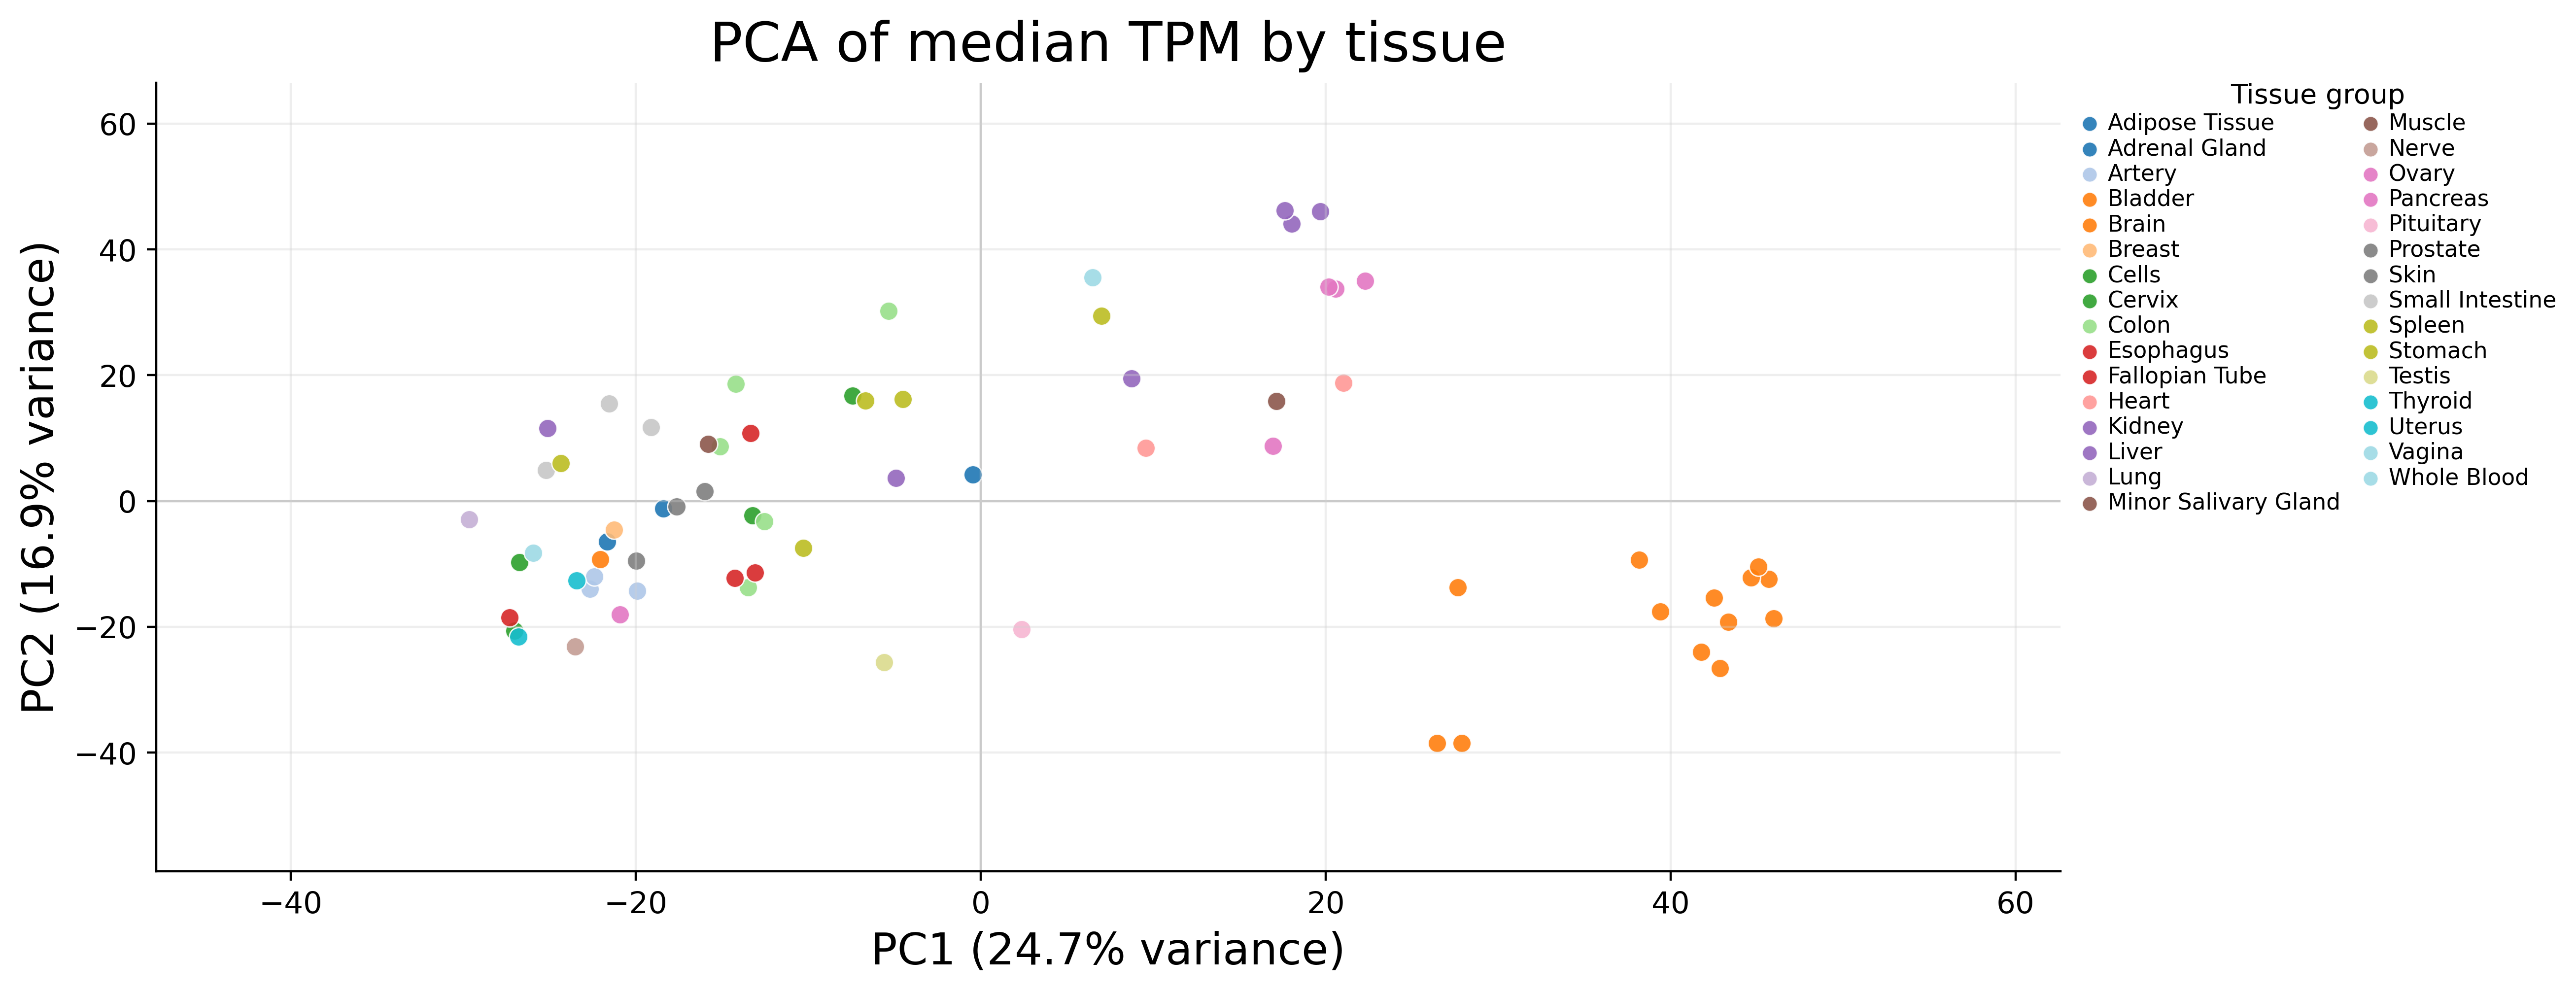

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA scatter of median TPM by tissue
tissue_columns = median_tpm_by_tissue.columns[2:]

parent_name_overrides = {
    'Adipose': 'Adipose Tissue',
    'Adrenal': 'Adrenal Gland',
    'Fallopian': 'Fallopian Tube',
    'Minor': 'Minor Salivary Gland',
    'Small': 'Small Intestine',
    'Whole': 'Whole Blood',
}

def parent_tissue_name(tissue_column):
    parent = tissue_column.split('_')[0]
    return parent_name_overrides.get(parent, parent)

def pca_label_name(tissue_column):
    parts = tissue_column.split('_')
    if len(parts) == 1:
        return tissue_column
    label = ' '.join(parts[1:])
    label_overrides = {
        'EBV transformed lymphocytes': 'EBV lymphocytes',
        'Transformed fibroblasts': 'Fibroblasts',
        'Sun Exposed Lower leg': 'Sun exposed',
        'Not Sun Exposed Suprapubic': 'Not sun exposed',
        'Gastroesophageal Junction': 'GE junction',
        'Anterior cingulate cortex BA24': 'Anterior cingulate',
        'Frontal Cortex BA9': 'Frontal cortex',
        'Nucleus accumbens basal ganglia': 'Nucleus accumbens',
        'Putamen basal ganglia': 'Putamen',
        'Caudate basal ganglia': 'Caudate',
        'Spinal cord cervical c-1': 'Spinal cord',
        'Cerebellar Hemisphere': 'Cerebellar hemi.',
    }
    return label_overrides.get(label, label)

pca_expression = (
    median_tpm_by_tissue.loc[:, tissue_columns]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

pca_data = np.log10(pca_expression + 1).T
pca_data = pca_data.loc[:, pca_data.std(axis=0) > 0]

pca = PCA(n_components=2, random_state=0)
pca_scores = pca.fit_transform(pca_data)
explained_variance_ratio = pca.explained_variance_ratio_

pca_df = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2'],
    index=pca_data.index,
)
pca_df['tissue_group'] = pd.Index(pca_df.index).map(parent_tissue_name)

groups = pd.Index(pca_df['tissue_group']).drop_duplicates()
group_palette = dict(zip(groups, plt.cm.tab20(np.linspace(0, 1, len(groups)))))

fig, ax = plt.subplots(figsize=(14, 5), dpi=400)

for group, group_df in pca_df.groupby('tissue_group', sort=False):
    ax.scatter(
        group_df['PC1'],
        group_df['PC2'],
        s=46,
        color=group_palette[group],
        label=group,
        edgecolor='white',
        linewidth=0.5,
        alpha=0.9,
    )

x_span = pca_df['PC1'].max() - pca_df['PC1'].min()
y_span = pca_df['PC2'].max() - pca_df['PC2'].min()
ax.set_xlim(pca_df['PC1'].min() - x_span * 0.24, pca_df['PC1'].max() + x_span * 0.22)
ax.set_ylim(pca_df['PC2'].min() - y_span * 0.24, pca_df['PC2'].max() + y_span * 0.24)

ax.axhline(0, color='0.78', linewidth=0.8, zorder=0)
ax.axvline(0, color='0.78', linewidth=0.8, zorder=0)
ax.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)", fontsize=16)
ax.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)", fontsize=16)
ax.set_title('PCA of median TPM by tissue', fontsize=20, pad=8)
ax.tick_params(axis='both', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='0.82', alpha=0.35, linewidth=0.8)

ax.legend(
    title='Tissue group',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=False,
    ncol=2,
    fontsize=8.2,
    title_fontsize=10,
    markerscale=0.82,
    borderaxespad=0,
    borderpad=0,
    handlelength=0.9,
    handletextpad=0.35,
    labelspacing=0.14,
    columnspacing=0.9,
)
fig.subplots_adjust(left=0.07, right=0.76, top=0.91, bottom=0.11)
plt.show()


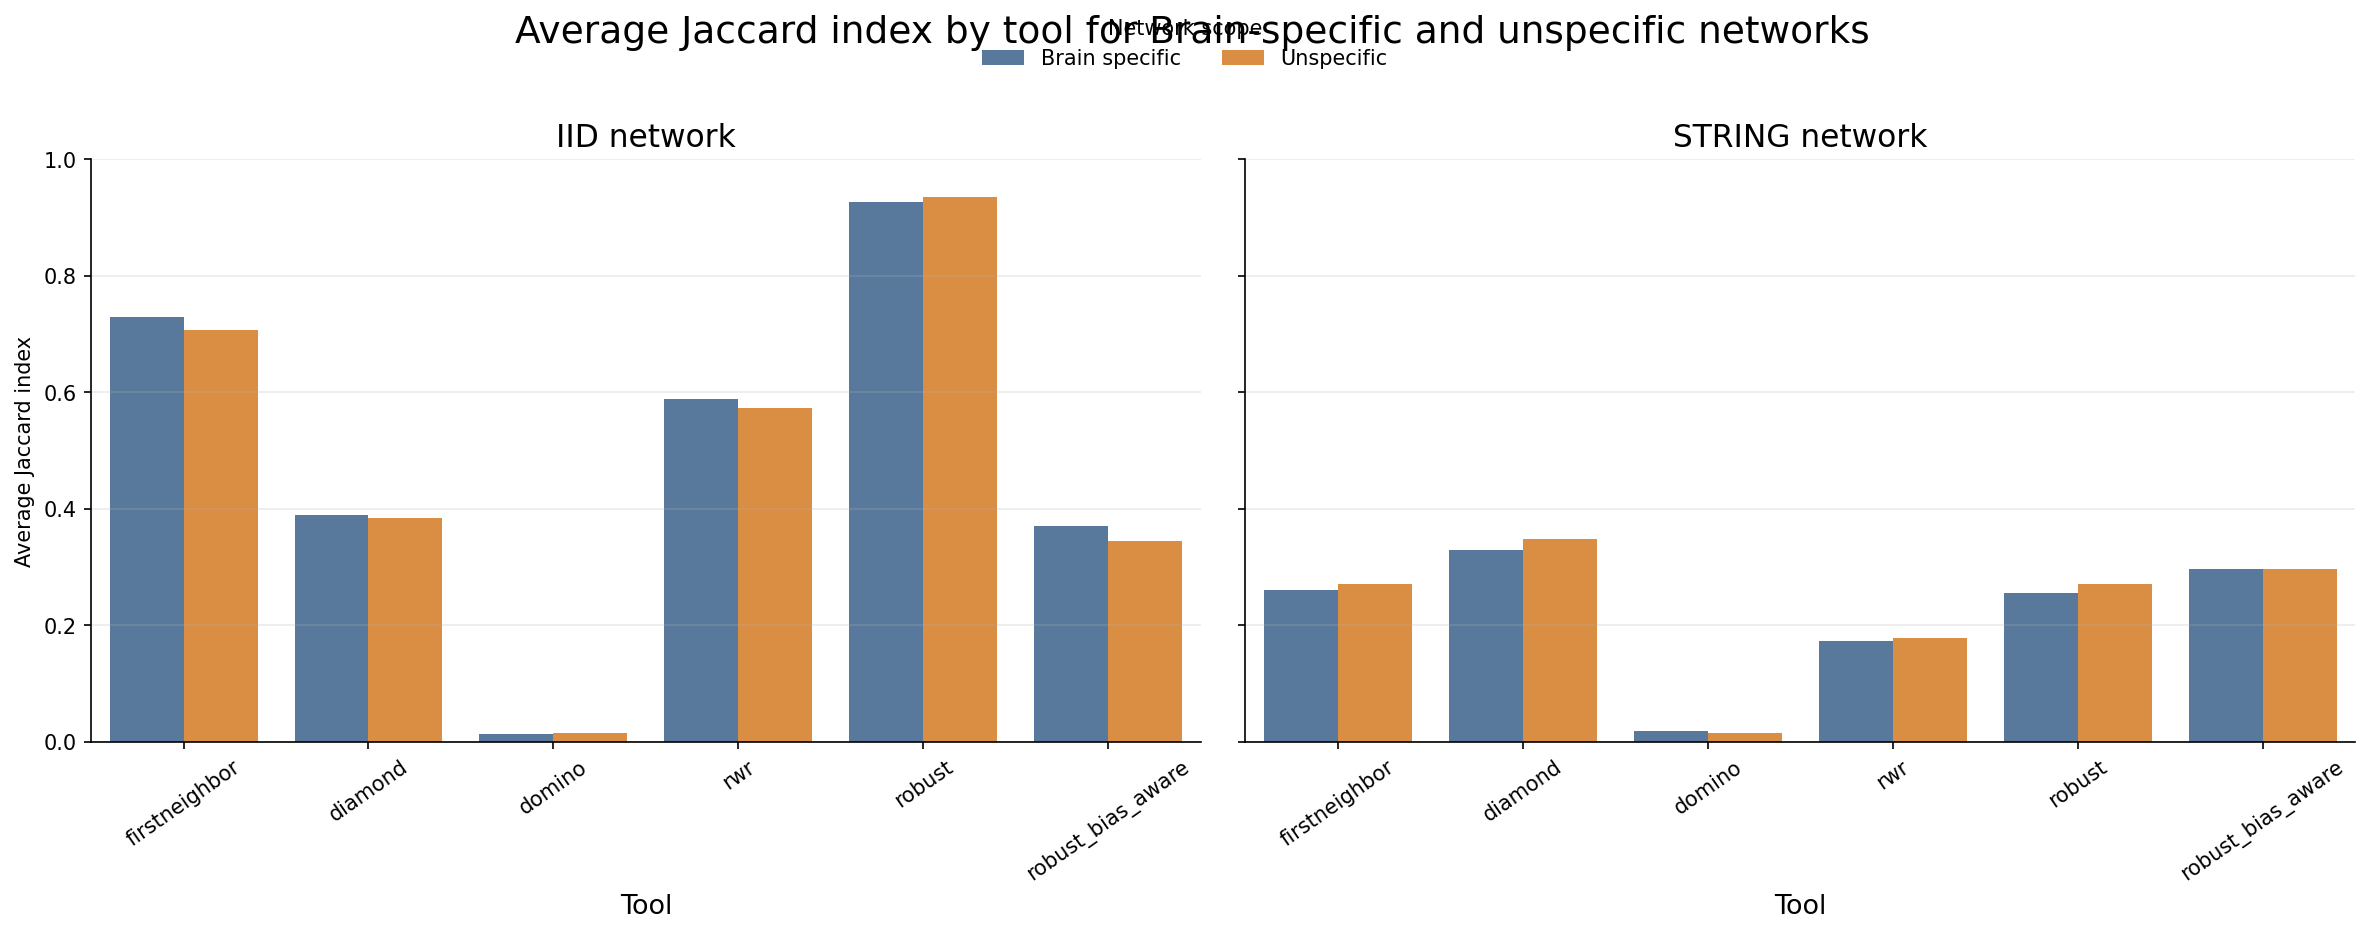

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mqc_path = Path("alzheimer_run_symbol_threshold_0.1/mqc_summaries/network_perturbation_mqc.tsv")
network_perturbation = pd.read_csv(mqc_path, sep="\t")


def parse_network_perturbation_id(identifier):
    identifier = str(identifier)
    iid_prefix = "symbol_ids.iid.human.Symbol."
    string_prefix = "symbol_ids.string.human_links_v12_0_min900.Symbol."

    if identifier.startswith(iid_prefix):
        network = "iid"
        rest = identifier[len(iid_prefix):]
    elif identifier.startswith(string_prefix):
        network = "string"
        rest = identifier[len(string_prefix):]
    else:
        network = "unknown"
        rest = identifier.split("Symbol.", 1)[-1] if "Symbol." in identifier else identifier

    parts = rest.split(".")
    tool = parts[-1]
    specificity = "Brain specific" if "Brain_Hippocampus" in parts[:-1] else "Unspecific"

    return pd.Series({"network": network, "specificity": specificity, "tool": tool})


parsed = network_perturbation["id"].apply(parse_network_perturbation_id)
plot_df = pd.concat([network_perturbation, parsed], axis=1)
plot_df["avg_jaccard_index"] = pd.to_numeric(plot_df["avg_jaccard_index"], errors="coerce")
plot_df = plot_df[plot_df["network"].isin(["iid", "string"])]

# Keep a stable, readable tool order across both panels.
tool_order = ["firstneighbor", "diamond", "domino", "rwr", "robust", "robust_bias_aware"]
specificity_order = ["Brain specific", "Unspecific"]
plot_df["tool"] = pd.Categorical(plot_df["tool"], categories=tool_order, ordered=True)
plot_df["specificity"] = pd.Categorical(plot_df["specificity"], categories=specificity_order, ordered=True)

palette = {
    "Brain specific": "#4e79a7",
    "Unspecific": "#f28e2b",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, dpi=150)

for ax, network in zip(axes, ["iid", "string"]):
    subset = plot_df[plot_df["network"] == network].copy()
    sns.barplot(
        data=subset,
        x="tool",
        y="avg_jaccard_index",
        hue="specificity",
        order=tool_order,
        hue_order=specificity_order,
        palette=palette,
        ax=ax,
    )

    ax.set_title(f"{network.upper()} network", fontsize=15)
    ax.set_xlabel("Tool", fontsize=13)
    ax.set_ylabel("Average Jaccard index" if network == "iid" else "")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax.get_legend() is not None:
        ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Network scope", loc="upper center", ncol=2, frameon=False)
fig.suptitle("Average Jaccard index by tool for Brain-specific and unspecific networks", fontsize=18, y=1.03)
fig.tight_layout()
plt.show()
